# Pregame minutes distributions

This notebook turns the saved appearance-conditional XGBoost **mean** model
into a **calibrated Monte Carlo distribution** for a player's minutes in an
upcoming game.

It does not retrain that mean model. Run
`notebooks/nba/minutes/xgboost_model.ipynb` through the save cell first so
`artifacts/models/minutes/xgboost_minutes.joblib` exists.

## Constraints

- One row per player-game.
- Every feature is knowable before tip-off.
- Actual Game N minutes and box-score stats are never inputs.
- Sportsbook DNPs **void** the wager; they are not graded as zero minutes.
- Silver gamelogs are appearance-conditional, so this distribution is
  **minutes | player plays**. `P(minutes = 0)` here is residual-clip mass
  (a handful of minutes, foul-out, or early exit), not P(healthy scratch).

## Decision

| Role | Method | Why |
|---|---|---|
| **Primary (production)** | Stratified residual bootstrap on the saved XGBoost mean | Native Monte Carlo, empirical skew and tails, reuses the tuned mean model, and stratification is the smallest fix for the current homoskedastic residual pool |
| **Baseline** | Quantile XGBoost (`reg:quantileerror`) | Independent of residual exchangeability; first-class heteroskedasticity; the right falsification check |

Poisson, negative binomial, and Tweedie are rejected as the data-generating
process. Minutes are bounded duration, not counts or insurance claims.
Conformalized quantile regression is kept as an **interval wrapper**, not as
the sampler. A hurdle / zero-inflated layer waits until a pregame candidate
universe exists.

The requested mean / median / PMF / percentiles are **minutes**, not points.
Points is a downstream convolution (usage rate × sampled minutes) and is
out of scope here.


## Approach comparison

NBA minutes are a mixture of rotation roles with a hard cap near 48 (63
with three overtimes), a long left tail from foul trouble and early
benches, and variance that **shrinks** as expected minutes rise. Star
minutes are tight; bench minutes are not. Any production sampler has to
represent that heteroskedasticity, the cap, and the empirical leftover
mass near zero **without** treating DNP as a countable zero.

### Quantile XGBoost

- **Assumptions.** Pinball loss is a consistent estimator of \(F^{-1}(\tau \mid x)\). Independent fits per \(\tau\) may cross. Interpolating a CDF between fitted knots is an extra assumption.
- **Zeros.** Only if zeros are in training. This dataset drops them, so the 5th percentile for rotation players will rarely be 0.
- **Skew / tails.** Yes. No parametric shape.
- **Heteroskedasticity.** Yes. The whole point.
- **Calibration.** Marginal coverage at each \(\tau\) can be checked. Crossing and tail interpolation are the failure modes. Does not produce a proper density without extra structure.
- **Cost.** One model per quantile. Seven quantiles at the production tree budget is cheap relative to the mean model.
- **Data.** Same pregame design matrix as the mean model.
- **Advantages.** No residual exchangeability. Direct answer to "what is p10 / p90?" Natural over/under at a line if the line is a fitted knot.
- **Weaknesses.** Not a generative model until you interpolate. Crossing. Weak between-knot density. Tail beyond p5/p95 is extrapolated.
- **NBA minutes.** Strong **baseline** and the right model for published percentile bands.
- **Production.** Baseline sampler, not the primary engine.

### Conditional residual bootstrap

- **Assumptions.** Mean model is approximately unbiased. Residuals are exchangeable, or exchangeable **within strata** of expected minutes. Error is additive on the minute scale. Clipping to \([0, 63]\) is acceptable.
- **Zeros.** Clipping creates some mass at 0. That is "played almost no minutes," not DNP.
- **Skew / tails.** Empirical. Keeps the foul-out left tail and garbage-time right tail that a Gaussian residual would erase.
- **Heteroskedasticity.** The current production code (`residual_scaling="raw"`) is **homoskedastic**. That is the main defect. Stratifying the residual pool by predicted-minute bins (or `start_rate_10`) is the production fix. `sqrt_mean` scaling is the parametric alternative; it is a better match for counts than for minutes.
- **Calibration.** Out-of-time residual pool (already stored on the saved model) plus holdout PIT / 80% coverage / NLL.
- **Cost.** One mean model. Sampling is \(O(nN)\).
- **Data.** Needs a chronological calibration window. The saved model already has  it.
- **Advantages.** Reuses the model you already trust for MAE. Native Monte Carlo. Full PMF, any threshold, any interval, from the same draws. Empirical leftover shape, including discreteness from how minutes are recorded.
- **Weaknesses.** A biased mean shifts the entire distribution. Unstratified pools steal variance from stars and give it to the bench. Additive residuals can land past 48 before clipping.
- **NBA minutes.** Best generative default for appearance-conditional minutes.
- **Production.** **Primary.** Use the saved residuals as the unstratified ablation; ship stratified residuals.

### Conformalized quantile regression

- **Assumptions.** Exchangeable conformal scores. Split conformal needs a held-out calibration window. Standard CQR expands both sides by the same additive correction, so it is not a conditional density.
- **Zeros.** No special handling.
- **Skew / tails.** Inherits the quantile model; the conformal step is typically symmetric.
- **Heteroskedasticity.** Only as much as the underlying quantile model already has. The additive correction is **not** locally adaptive unless you use localized/weighted CQR.
- **Calibration.** Finite-sample **marginal** coverage guarantee. Not conditional coverage given "this is a 36-minute starter."
- **Cost.** One extra calibration pass. Cheap.
- **Data.** Requires a dedicated conformal split. We already have `training_cutoff`.
- **Advantages.** Honest 80% / 90% bands when you cannot afford to lie about coverage.
- **Weaknesses.** Not a PMF. Intervals often too wide. Cannot sample a Monte Carlo path from a conformal band alone.
- **NBA minutes.** Use it to **audit** interval width, not to simulate.
- **Production.** Wrapper around quantile 10–90. Not the sampler.

### Negative binomial regression

- **Assumptions.** Integer counts. Variance \(= \mu + \alpha\mu^2\). Equidispersion is a special case \(\alpha = 0\).
- **Zeros.** Some mass at 0 when \(\mu\) is small. That mass is "low count," not "did not play."
- **Skew / tails.** Right-skewed. Unbounded above. No 48-minute cap.
- **Heteroskedasticity.** Locked to the mean. Bench minutes are noisy for rotation reasons, not because \(\mu\) is small in an NB sense. Stars at \(\mu = 36\) are **less** variable than NB would predict.
- **Calibration.** Usually under-dispersed in the star tail and wrong at the cap.
- **Cost.** Cheap GLM or boosting with a count objective.
- **Data.** Moderate. Needs integer targets, which minutes only approximately are.
- **Advantages.** Overdispersion relative to Poisson. Familiar in sports analytics for **counting stats**.
- **Weaknesses.** Minutes are duration. Overtime, blowout rest, and the 48-minute ceiling are outside the support. Integer-ness is a recording artifact.
- **NBA minutes.** Misspecified. Do not use for minutes. Keep NB for points **conditional on minutes**.
- **Production.** **No.**

### Poisson regression

- Same indictment as NB, plus equidispersion. Residual variance of minutes is not \(\sqrt{\mu}\).
- **Production.** **No.**

### Tweedie regression

- **Assumptions.** Compound Poisson–gamma. Mass at zero from a no-claim Poisson process; positive outcomes continuous gamma. Mean-variance power law.
- **Zeros.** The zero is "no insurance claim," which is the wrong metaphor for a DNP or a coach's decision.
- **Skew / tails.** Yes, but unbounded and not capped at 48.
- **Heteroskedasticity.** Power-law, not role-driven.
- **Calibration.** Extra parameter \(p \in (1,2)\) to tune. Easy to overfit.
- **Cost.** Moderate. Supported in XGBoost / LightGBM.
- **NBA minutes.** The zero process and the positive process are not a compound Poisson. **No.**
- **Production.** **No.**

### Zero-inflated and hurdle models

- **Assumptions.** Hurdle: \(P(\text{play}) \times F(\text{minutes} \mid \text{play})\). ZIP/ZINB: extra zeros from the **same** count process.
- **Zeros.** This is the only family that treats P(play) as first-class. That is the right **factorization**.
- **Skew / tails.** Only as good as the positive-part model. ZIP + Poisson is still a count model.
- **Heteroskedasticity.** Same issue as the positive-part model.
- **Calibration.** Two models, two calibration problems. The appearance model needs a candidate universe (active + DNP + healthy scratch).
- **Cost.** Double. The bottleneck is data, not compute.
- **Data.** Silver gamelogs almost never include documented DNPs. Until that universe exists, you cannot train P(play) without leaking "this player appeared in the log."
- **Advantages.** Conceptually correct for DFS and for an availability layer.
- **Weaknesses.** Sportsbooks **void** DNP; mixing zeros into the minutes density double-counts availability. ZIP is the wrong zero process even when the data exist. Hurdle + residual bootstrap is the version worth building later.
- **NBA minutes.** Right architecture, wrong time. Keep `availability_probability` as an external settlement input.
- **Production.** **Not now.** Revisit when Rotowire / injury / active-status history is a first-class pregame table.

### Empirical nearest-neighbor distributions

- **Assumptions.** Local exchangeability in a small pregame feature space (recent minutes, start rate, spread).
- **Zeros.** Only if neighbors include zeros.
- **Skew / tails.** Empirical and local. Good.
- **Heteroskedasticity.** Local by construction.
- **Calibration.** No guarantee. Curse of dimensionality as soon as you use the full 37-feature list.
- **Cost.** Cheap at \(k \approx 150\) in 3–5 dimensions. Painful in 37.
- **Data.** Needs density. Early-season and traded players have bad neighborhoods.
- **Advantages.** Transparent. Excellent "what did similar roles actually do?" diagnostic. Hard to overfit if the feature list is tiny.
- **Weaknesses.** Not a model of the mean you already trained. Neighborhoods ignore opponent and market features unless you add them, at which point the neighborhood empties.
- **NBA minutes.** Ship as a **sanity-check baseline**, not the engine.
- **Production.** Diagnostic only.

### Distributional boosting (NGBoost, parametric XGBoost)

- **Assumptions.** A named likelihood (Normal, LogNormal, Student-t, Poisson, …) whose parameters are boosted. Normal is symmetric and unbounded. LogNormal cannot hit 0 and has a heavy right tail past 48.
- **Zeros.** Only with a zero-inflated or censored likelihood, which these libraries do not give you for free.
- **Skew / tails.** Only if you pick the right family. We do not have one.
- **Heteroskedasticity.** Yes, via a variance head. That is the appeal.
- **Calibration.** Requires the likelihood to be true. It is not.
- **Cost.** Higher than a mean model. More hyperparameters.
- **Data.** Same design matrix, plus enough data to identify a variance function.
- **Advantages.** Closed-form density, no interpolation, no residual pool.
- **Weaknesses.** The parametric shape fight with the 48-minute cap, the left tail, and the role mixture. You will spend the savings on a truncated / censored patch.
- **NBA minutes.** Inferior to residual bootstrap plus a quantile check.
- **Production.** **Not yet.** Revisit only if you need a closed-form density for a downstream Bayesian layer.

## What I would not debate in a model review

Poisson, NB, and Tweedie as **minutes** samplers. They are the right tools
for **points | minutes**. Using them here confuses the volume module with
the counting module.


In [1]:
from pathlib import Path
import sys
import json
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.neighbors import NearestNeighbors
from xgboost import XGBRegressor

ROOT = Path("/Users/alexgonzalez/Documents/nba_quant")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.features.minutes import add_minutes_features
from src.models.evaluation import (
    interval_coverage,
    negative_log_likelihood,
    probability_integral_transform,
)
from src.models.settlement import maximum_minutes

ARTIFACT_DIR = ROOT / "artifacts" / "models" / "minutes"
ARTIFACT_PATH = ARTIFACT_DIR / "xgboost_minutes.joblib"
META_PATH = ARTIFACT_DIR / "xgboost_minutes_meta.json"

N_SIM_EVAL = 2_000
N_SIM_PLAYER = 10_000
QUANTILES = np.array([0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95])
MAX_MINUTES = maximum_minutes("nba")
MINUTE_BINS = np.array([0.0, 12.0, 18.0, 24.0, 30.0, 36.0, 64.0])
RNG_SEED = 42

sns.set_theme(style="whitegrid")

if not ARTIFACT_PATH.exists():
    raise FileNotFoundError(
        "Missing saved minutes model at "
        f"{ARTIFACT_PATH}. Run notebooks/nba/minutes/xgboost_model.ipynb "
        "through the save cell first."
    )

payload = joblib.load(ARTIFACT_PATH)
model = payload["model"]
feature_columns = list(payload["feature_columns"])
holdout_season = payload["holdout_season"]
training_cutoff = pd.Timestamp(payload["training_cutoff"])

print(f"Loaded {ARTIFACT_PATH}")
print(f"League: {payload['league']}")
print(f"Features: {len(feature_columns)}")
print(f"Trees: {payload['n_estimators']}")
print(f"Residual scaling: {payload['residual_scaling']}")
print(f"Calibration cutoff: {training_cutoff.date()}")
print(f"Holdout season: {holdout_season}")
print(
    "Calibration residuals: "
    f"{len(model.regressor.calibration_residuals):,}"
)
if META_PATH.exists():
    meta = json.loads(META_PATH.read_text())
    print(f"Train rows at save: {meta['n_train']:,}")
    print(f"Test rows at save: {meta['n_test']:,}")


Loaded /Users/alexgonzalez/Documents/nba_quant/artifacts/models/minutes/xgboost_minutes.joblib
League: nba
Features: 37
Trees: 750
Residual scaling: raw
Calibration cutoff: 2024-03-18
Holdout season: 2025-26
Calibration residuals: 140,780
Train rows at save: 150,062
Test rows at save: 26,648


In [2]:
SILVER = ROOT / "data/silver/nba"
seasons = [
    "2019-20",
    "2020-21",
    "2021-22",
    "2022-23",
    "2023-24",
    "2024-25",
    "2025-26",
]
frames = [
    pd.read_parquet(
        SILVER / season / "regular_season" / "player_gamelogs.parquet"
    )
    for season in seasons
]
df = pd.concat(frames, ignore_index=True)
df = add_minutes_features(df)

n_zero = int((df["minutes"] <= 0).sum())
print(f"Rows: {len(df):,}")
print(f"Zero-minute rows in silver: {n_zero:,}")
print(
    "Silver is appearance-conditional; zeros are not a DNP universe. "
    "P(minutes = 0) below is residual-clip mass given that the player played."
)


Rows: 176,738
Zero-minute rows in silver: 28
Silver is appearance-conditional; zeros are not a DNP universe. P(minutes = 0) below is residual-clip mass given that the player played.


In [3]:
appearances = df.loc[df["minutes"].gt(0)].copy()
appearances["game_date"] = pd.to_datetime(appearances["game_date"])

train = appearances.loc[appearances["season_year"] != holdout_season].copy()
test = appearances.loc[appearances["season_year"] == holdout_season].copy()
calibration = train.loc[train["game_date"] >= training_cutoff].copy()
development = train.loc[train["game_date"] < training_cutoff].copy()

missing = [c for c in feature_columns if c not in appearances.columns]
if missing:
    raise ValueError(f"Missing features: {missing}")

print(f"Train: {len(train):,}")
print(f"Development: {len(development):,}")
print(f"Calibration window: {len(calibration):,}")
print(f"Holdout: {len(test):,}")
print(
    "All features are lagged / pregame constructs from "
    "src.features.minutes; current-game minutes are the target only."
)


Train: 150,062
Development: 119,055
Calibration window: 31,007
Holdout: 26,648
All features are lagged / pregame constructs from src.features.minutes; current-game minutes are the target only.


In [4]:
def feature_matrix(frame: pd.DataFrame) -> pd.DataFrame:
    matrix = frame.loc[:, feature_columns].copy()
    for column in matrix.columns:
        matrix[column] = pd.to_numeric(matrix[column], errors="coerce")
    return matrix


def clip_minutes(values: np.ndarray) -> np.ndarray:
    return np.clip(np.asarray(values, dtype=float), 0.0, MAX_MINUTES)


def summarize_draws(
    draws: np.ndarray,
    *,
    threshold: float | None = None,
    n_bootstrap: int = 400,
    random_seed: int = RNG_SEED,
) -> dict:
    """Summarize one player's Monte Carlo minutes draws.

    Interval uncertainty is the bootstrap standard error of each
    percentile across resamples of the N draws — a measure of Monte
    Carlo error, not of minutes volatility. Minutes volatility is std
    / IQR / interval width.
    """
    samples = np.asarray(draws, dtype=float).ravel()
    rounded = np.rint(samples)
    values, counts = np.unique(rounded, return_counts=True)
    pmf = pd.Series(counts / counts.sum(), index=values.astype(int), name="probability")

    percentile_grid = {
        "p5": 0.05,
        "p10": 0.10,
        "p25": 0.25,
        "p50": 0.50,
        "p75": 0.75,
        "p90": 0.90,
        "p95": 0.95,
    }
    percentiles = {
        name: float(np.quantile(samples, q))
        for name, q in percentile_grid.items()
    }

    rng = np.random.default_rng(random_seed)
    boot = rng.choice(samples, size=(n_bootstrap, len(samples)), replace=True)
    percentile_se = {
        f"{name}_mc_se": float(np.std(np.quantile(boot, q, axis=1), ddof=1))
        for name, q in percentile_grid.items()
    }

    probs = pmf.to_numpy()
    entropy = float(-(probs * np.log(np.clip(probs, 1e-12, 1))).sum())

    summary = {
        "n_sim": int(len(samples)),
        "mean": float(samples.mean()),
        "median": float(np.median(samples)),
        "std": float(samples.std(ddof=1)),
        "cv": float(samples.std(ddof=1) / max(samples.mean(), 1e-6)),
        "iqr": percentiles["p75"] - percentiles["p25"],
        "interval_80_low": percentiles["p10"],
        "interval_80_high": percentiles["p90"],
        "interval_80_width": percentiles["p90"] - percentiles["p10"],
        "interval_90_low": percentiles["p5"],
        "interval_90_high": percentiles["p95"],
        "interval_90_width": percentiles["p95"] - percentiles["p5"],
        "p_zero": float(np.mean(samples <= 0.5)),
        "mean_mc_se": float(samples.std(ddof=1) / np.sqrt(len(samples))),
        "pmf_entropy": entropy,
        "pmf_support": int(len(pmf)),
        **percentiles,
        **percentile_se,
    }
    if threshold is not None:
        summary["recent_avg"] = float(threshold)
        summary["p_over_avg"] = float(np.mean(samples > threshold))
        summary["p_under_avg"] = float(np.mean(samples < threshold))
    return summary, pmf


def recent_avg_minutes(row: pd.Series) -> float | None:
    """Pregame trailing average. DFS does not post a minutes line."""
    value = row.get("min_mean_10")
    if value is None or pd.isna(value):
        return None
    return float(value)


def print_player_report(
    row: pd.Series,
    draws: np.ndarray,
    *,
    threshold: float | None = None,
) -> pd.Series:
    if threshold is None:
        threshold = recent_avg_minutes(row)
    summary, pmf = summarize_draws(draws, threshold=threshold)
    name = row.get("player_name", "player")
    matchup = row.get("matchup", "")
    date = pd.Timestamp(row["game_date"]).date()
    print(f"{name} · {matchup} · {date}")
    print(
        f"mean {summary['mean']:.2f}  median {summary['median']:.2f}  "
        f"std {summary['std']:.2f}  P(0) {summary['p_zero']:.3f}"
    )
    print(
        "percentiles  "
        f"5={summary['p5']:.1f}  10={summary['p10']:.1f}  "
        f"25={summary['p25']:.1f}  50={summary['p50']:.1f}  75={summary['p75']:.1f}  "
        f"90={summary['p90']:.1f}  95={summary['p95']:.1f}"
    )
    print(
        f"80% PI [{summary['interval_80_low']:.1f}, "
        f"{summary['interval_80_high']:.1f}]  "
        f"90% PI [{summary['interval_90_low']:.1f}, "
        f"{summary['interval_90_high']:.1f}]"
    )
    if threshold is not None:
        print(
            f"last-10 avg {threshold:.1f}  "
            f"P(over avg) {summary['p_over_avg']:.3f}  "
            f"P(under avg) {summary['p_under_avg']:.3f}"
        )
    print(
        "MC error of mean "
        f"{summary['mean_mc_se']:.4f}  "
        f"PMF entropy {summary['pmf_entropy']:.2f}  "
        f"support {summary['pmf_support']} minutes"
    )
    display_pmf = pmf.loc[pmf >= 0.01].sort_index()
    return pd.Series(summary), display_pmf


In [5]:
def residual_bin_id(centers: np.ndarray) -> np.ndarray:
    return np.clip(np.digitize(centers, MINUTE_BINS) - 1, 0, len(MINUTE_BINS) - 2)


def fit_stratified_residual_pools(
    frame: pd.DataFrame,
) -> dict[int, np.ndarray]:
    """Build residual pools on the chronological calibration window.

    Pools use the saved (refitted) mean model, so they are slightly
    tighter than the pre-refit residuals stored on the model. Holdout
    scoring below remains out-of-time.
    """
    centers = model.predict_mean(frame)
    residuals = frame["minutes"].to_numpy(dtype=float) - centers
    lower, upper = np.quantile(residuals, [0.005, 0.995])
    residuals = np.clip(residuals, lower, upper)
    bins = residual_bin_id(centers)
    pools: dict[int, np.ndarray] = {}
    for bin_id in range(len(MINUTE_BINS) - 1):
        pool = residuals[bins == bin_id]
        if len(pool) >= 40:
            pools[bin_id] = pool
    if not pools:
        raise ValueError("No residual pool had 40 or more rows.")
    return pools


def simulate_stratified(
    frame: pd.DataFrame,
    pools: dict[int, np.ndarray],
    *,
    simulations: int,
    random_seed: int = RNG_SEED,
) -> np.ndarray:
    centers = model.predict_mean(frame)
    bins = residual_bin_id(centers)
    rng = np.random.default_rng(random_seed)
    fallback = np.concatenate(list(pools.values()))
    draws = np.empty((len(centers), simulations), dtype=float)
    for bin_id in np.unique(bins):
        mask = bins == bin_id
        pool = pools.get(int(bin_id), fallback)
        sampled = rng.choice(pool, size=(int(mask.sum()), simulations), replace=True)
        draws[mask] = centers[mask, None] + sampled
    return clip_minutes(draws)


stratified_pools = fit_stratified_residual_pools(calibration)

print("Stratified residual pools (calibration window)")
for bin_id, pool in sorted(stratified_pools.items()):
    lo = MINUTE_BINS[bin_id]
    hi = MINUTE_BINS[bin_id + 1]
    print(
        f"  [{lo:.0f}, {hi:.0f})  n={len(pool):5d}  "
        f"std={pool.std():.2f}  mean={pool.mean():+.2f}"
    )


Stratified residual pools (calibration window)
  [0, 12)  n= 4843  std=6.07  mean=-0.30
  [12, 18)  n= 5276  std=6.83  mean=+0.07
  [18, 24)  n= 5969  std=6.49  mean=+0.20
  [24, 30)  n= 7012  std=5.87  mean=-0.02
  [30, 36)  n= 7013  std=4.99  mean=+0.16
  [36, 64)  n=  894  std=4.34  mean=+0.51


In [6]:
def new_quantile_model(alpha: float, n_estimators: int) -> XGBRegressor:
    return XGBRegressor(
        objective="reg:quantileerror",
        quantile_alpha=alpha,
        n_estimators=n_estimators,
        learning_rate=0.03,
        max_depth=4,
        min_child_weight=10.0,
        subsample=0.80,
        colsample_bytree=0.80,
        reg_alpha=0.10,
        reg_lambda=5.0,
        tree_method="hist",
        n_jobs=-1,
        random_state=RNG_SEED,
        early_stopping_rounds=100,
    )


def fit_quantile_models() -> dict[float, XGBRegressor]:
    x_dev = feature_matrix(development)
    x_cal = feature_matrix(calibration)
    y_dev = development["minutes"].to_numpy(dtype=float)
    y_cal = calibration["minutes"].to_numpy(dtype=float)
    n_estimators = int(model.regressor.model.n_estimators)
    fitted: dict[float, XGBRegressor] = {}
    for alpha in QUANTILES:
        candidate = new_quantile_model(float(alpha), n_estimators)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            candidate.fit(
                x_dev,
                y_dev,
                eval_set=[(x_cal, y_cal)],
                verbose=False,
            )
        fitted[float(alpha)] = candidate
        print(
            f"quantile {alpha:.2f}  trees={candidate.best_iteration + 1}  "
            f"best={candidate.best_score:.3f}"
        )
    return fitted


quantile_models = fit_quantile_models()


quantile 0.05  trees=750  best=0.635
quantile 0.10  trees=750  best=1.056
quantile 0.25  trees=749  best=1.896
quantile 0.50  trees=750  best=2.404
quantile 0.75  trees=750  best=1.954
quantile 0.90  trees=750  best=1.117
quantile 0.95  trees=750  best=0.674


In [7]:
def predict_quantiles(frame: pd.DataFrame) -> np.ndarray:
    x = feature_matrix(frame)
    raw = np.column_stack(
        [quantile_models[float(alpha)].predict(x) for alpha in QUANTILES]
    )
    # Enforce non-decreasing quantiles per row (no crossing).
    return np.maximum.accumulate(clip_minutes(raw), axis=1)


def quantile_function_knots(quantile_pred: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Extend fitted knots to τ=0 and τ=1 with linear tails, then clip."""
    q05, q10, q90, q95 = (
        quantile_pred[:, 0],
        quantile_pred[:, 1],
        quantile_pred[:, 5],
        quantile_pred[:, 6],
    )
    q00 = clip_minutes(2 * q05 - q10)
    q100 = clip_minutes(2 * q95 - q90)
    knots = np.column_stack([q00, quantile_pred, q100])
    tau = np.concatenate([[0.0], QUANTILES, [1.0]])
    return tau, np.maximum.accumulate(knots, axis=1)


def simulate_quantiles(
    frame: pd.DataFrame,
    *,
    simulations: int,
    random_seed: int = RNG_SEED,
) -> np.ndarray:
    tau, knots = quantile_function_knots(predict_quantiles(frame))
    rng = np.random.default_rng(random_seed)
    uniforms = rng.random((len(knots), simulations))
    draws = np.empty_like(uniforms)
    for i, row in enumerate(knots):
        draws[i] = np.interp(uniforms[i], tau, row)
    return clip_minutes(draws)


def conformal_interval(
    frame: pd.DataFrame,
    *,
    lower: float = 0.10,
    upper: float = 0.90,
) -> tuple[np.ndarray, np.ndarray, float]:
    """Split-CQR around the fitted 10–90 quantile band."""
    cal_q = predict_quantiles(calibration)
    idx = {float(a): i for i, a in enumerate(QUANTILES)}
    q_lo = cal_q[:, idx[lower]]
    q_hi = cal_q[:, idx[upper]]
    y = calibration["minutes"].to_numpy(dtype=float)
    scores = np.maximum(q_lo - y, y - q_hi)
    n = len(scores)
    level = np.ceil((n + 1) * (1 - (upper - lower))) / n
    level = float(np.clip(level, 0.0, 1.0))
    qhat = float(np.quantile(scores, min(level, 1.0)))

    pred = predict_quantiles(frame)
    lo = clip_minutes(pred[:, idx[lower]] - qhat)
    hi = clip_minutes(pred[:, idx[upper]] + qhat)
    return lo, hi, qhat


In [8]:
NN_FEATURES = [
    "min_mean_10",
    "start_rate_10",
    "min_std_10",
    "abs_spread",
]
K_NEIGHBORS = 150


def fit_empirical_neighbors() -> tuple[NearestNeighbors, np.ndarray, np.ndarray]:
    train_x = feature_matrix(train)[NN_FEATURES].to_numpy(dtype=float)
    med = np.nanmedian(train_x, axis=0)
    scale = np.nanstd(train_x, axis=0)
    scale = np.where(scale < 1e-6, 1.0, scale)
    standardized = np.where(np.isfinite(train_x), (train_x - med) / scale, 0.0)
    neighbor_model = NearestNeighbors(n_neighbors=K_NEIGHBORS, algorithm="auto")
    neighbor_model.fit(standardized)
    minutes = train["minutes"].to_numpy(dtype=float)
    return neighbor_model, minutes, np.vstack([med, scale])


nn_model, nn_minutes, nn_stats = fit_empirical_neighbors()


def simulate_neighbors(
    frame: pd.DataFrame,
    *,
    simulations: int,
    random_seed: int = RNG_SEED,
) -> np.ndarray:
    med, scale = nn_stats
    test_x = feature_matrix(frame)[NN_FEATURES].to_numpy(dtype=float)
    standardized = np.where(np.isfinite(test_x), (test_x - med) / scale, 0.0)
    indices = nn_model.kneighbors(standardized, return_distance=False)
    rng = np.random.default_rng(random_seed)
    picks = rng.integers(0, K_NEIGHBORS, size=(len(frame), simulations))
    row_ids = np.arange(len(frame))[:, None]
    return clip_minutes(nn_minutes[indices[row_ids, picks]])


print(
    f"Empirical NN baseline: k={K_NEIGHBORS} in {NN_FEATURES} "
    f"on {len(train):,} training appearances."
)


Empirical NN baseline: k=150 in ['min_mean_10', 'start_rate_10', 'min_std_10', 'abs_spread'] on 150,062 training appearances.


In [9]:
EVAL_N = min(4_000, len(test))
eval_frame = (
    test.sort_values("game_date")
    .tail(EVAL_N)
    .copy()
)
actual = eval_frame["minutes"].to_numpy(dtype=float)

samples = {
    "production_bootstrap": model.simulate(
        eval_frame, simulations=N_SIM_EVAL
    ),
    "stratified_bootstrap": simulate_stratified(
        eval_frame, stratified_pools, simulations=N_SIM_EVAL
    ),
    "quantile_xgb": simulate_quantiles(
        eval_frame, simulations=N_SIM_EVAL
    ),
    "empirical_nn": simulate_neighbors(
        eval_frame, simulations=N_SIM_EVAL
    ),
}

cqr_lo, cqr_hi, cqr_qhat = conformal_interval(eval_frame)
quantile_band = predict_quantiles(eval_frame)
q_idx = {float(a): i for i, a in enumerate(QUANTILES)}


def score_sampler(name: str, draws: np.ndarray) -> dict:
    pit = probability_integral_transform(draws, actual)
    median = np.median(draws, axis=1)
    return {
        "method": name,
        "n": len(eval_frame),
        "mae_median": float(np.mean(np.abs(median - actual))),
        "coverage_80": interval_coverage(draws, actual, lower=0.10, upper=0.90),
        "coverage_90": interval_coverage(draws, actual, lower=0.05, upper=0.95),
        "pit_mean": float(pit.mean()),
        "pit_std": float(pit.std()),
        "nll": negative_log_likelihood(draws, actual),
        "mean_std": float(draws.std(axis=1).mean()),
        "p_zero": float(np.mean(draws <= 0.5)),
    }


comparison = pd.DataFrame(
    [score_sampler(name, draws) for name, draws in samples.items()]
)

raw_80 = float(
    np.mean(
        (actual >= quantile_band[:, q_idx[0.10]])
        & (actual <= quantile_band[:, q_idx[0.90]])
    )
)
cqr_80 = float(np.mean((actual >= cqr_lo) & (actual <= cqr_hi)))
interval_audit = pd.DataFrame(
    [
        {
            "method": "quantile_xgb_10_90",
            "coverage_80": raw_80,
            "mean_width": float(
                (quantile_band[:, q_idx[0.90]] - quantile_band[:, q_idx[0.10]]).mean()
            ),
        },
        {
            "method": "cqr_10_90",
            "coverage_80": cqr_80,
            "mean_width": float((cqr_hi - cqr_lo).mean()),
            "qhat": cqr_qhat,
        },
    ]
)

print(
    f"Holdout scoring frame: last {len(eval_frame):,} 2025-26 appearances "
    f"({eval_frame['game_date'].min().date()} → "
    f"{eval_frame['game_date'].max().date()})."
)
print("CRPS omitted: pairwise CRPS is too expensive at this draw count.")
display(comparison.round(3))
print("Interval audit (quantile band vs conformal wrapper)")
display(interval_audit.round(3))
print(
    "Read: coverage_80 target ≈ 0.80. PIT mean ≈ 0.50 and PIT std ≈ 0.29 "
    "if Uniform(0,1). Low coverage + U-shaped PIT = too tight. "
    "NLL is comparable only across samplers on this same frame."
)


Holdout scoring frame: last 4,000 2025-26 appearances (2026-03-20 → 2026-04-12).
CRPS omitted: pairwise CRPS is too expensive at this draw count.


,method,n,mae_median,coverage_80,coverage_90,pit_mean,pit_std,nll,mean_std,p_zero
0,production_bootstrap,4000,5.156,0.773,0.877,0.502,0.297,3.331,6.093,0.020
1,stratified_bootstrap,4000,5.134,0.765,0.866,0.502,0.300,3.305,5.993,0.016
2,quantile_xgb,4000,5.259,0.783,0.888,0.509,0.293,3.348,6.098,0.002
3,empirical_nn,4000,5.718,0.776,0.876,0.510,0.294,3.518,6.895,0.003


Interval audit (quantile band vs conformal wrapper)


,method,coverage_80,mean_width,qhat
0,quantile_xgb_10_90,0.779,15.756,NaN
1,cqr_10_90,0.209,4.072,-5.842


Read: coverage_80 target ≈ 0.80. PIT mean ≈ 0.50 and PIT std ≈ 0.29 if Uniform(0,1). Low coverage + U-shaped PIT = too tight. NLL is comparable only across samplers on this same frame.


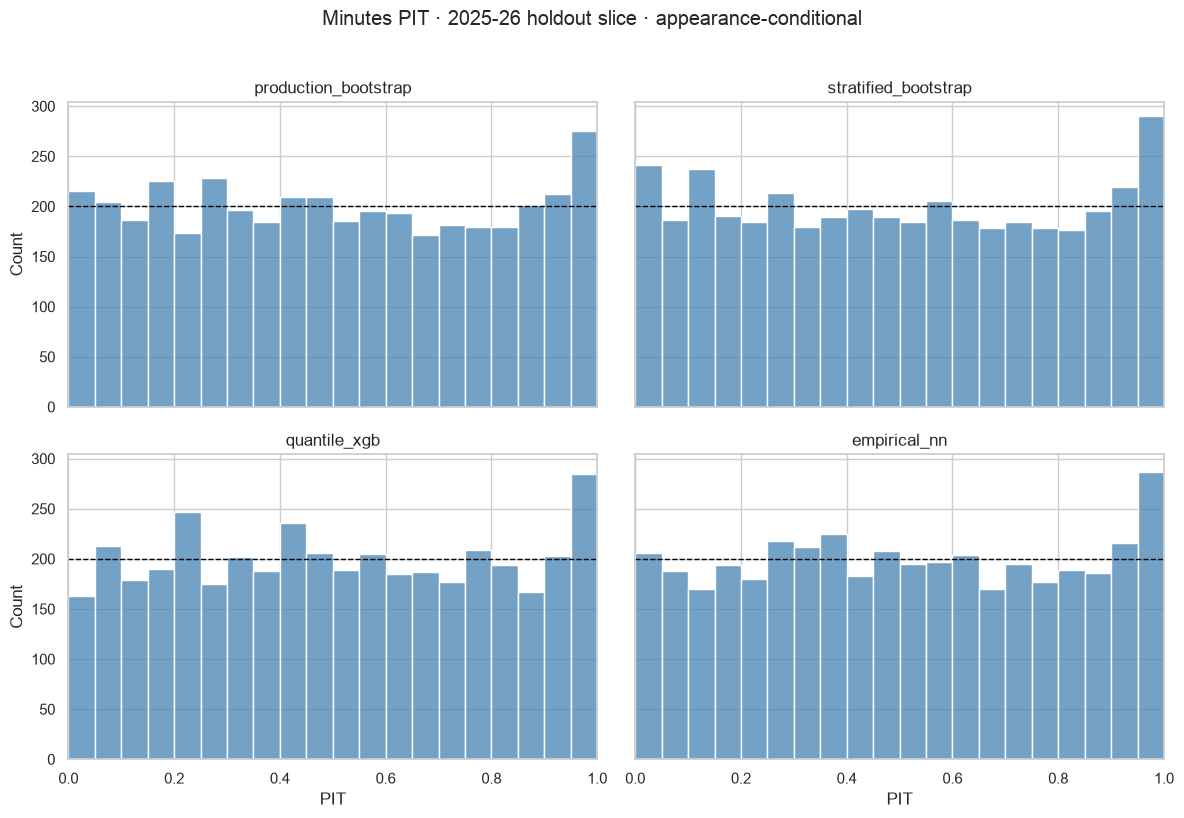

In [10]:
eval_frame = eval_frame.copy()
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
for axis, (name, draws) in zip(axes.ravel(), samples.items()):
    pit = probability_integral_transform(draws, actual)
    sns.histplot(
        pit,
        bins=20,
        binrange=(0, 1),
        ax=axis,
        color="steelblue",
    )
    axis.axhline(
        len(pit) / 20,
        color="black",
        linestyle="--",
        linewidth=1,
    )
    axis.set_title(name)
    axis.set_xlim(0, 1)
    axis.set_xlabel("PIT")
fig.suptitle(
    "Minutes PIT · 2025-26 holdout slice · appearance-conditional",
    y=1.02,
)
fig.tight_layout()
plt.show()


In [11]:
# Role slice: does stratification actually widen bench and tighten stars?
eval_frame["expected_starter"] = eval_frame["start_rate_10"] >= 0.5
role_rows = []
for role_name, mask in (
    ("expected_starter", eval_frame["expected_starter"].fillna(False)),
    ("expected_bench", ~eval_frame["expected_starter"].fillna(True)),
):
    if mask.sum() < 50:
        continue
    for method, draws in samples.items():
        pit = probability_integral_transform(draws[mask.to_numpy()], actual[mask.to_numpy()])
        role_rows.append(
            {
                "role": role_name,
                "method": method,
                "n": int(mask.sum()),
                "coverage_80": interval_coverage(
                    draws[mask.to_numpy()], actual[mask.to_numpy()]
                ),
                "pit_mean": float(pit.mean()),
                "mean_std": float(draws[mask.to_numpy()].std(axis=1).mean()),
                "nll": negative_log_likelihood(
                    draws[mask.to_numpy()], actual[mask.to_numpy()]
                ),
            }
        )

role_comparison = pd.DataFrame(role_rows)
display(role_comparison.round(3))
print(
    "The production bootstrap should look too tight on expected bench "
    "and/or too wide on expected starters. Stratification is doing its "
    "job if bench std rises and starter coverage moves toward 0.80."
)


,role,method,n,coverage_80,pit_mean,mean_std,nll
0,expected_starter,production_bootstrap,1647,0.848,0.501,6.183,3.168
1,expected_starter,stratified_bootstrap,1647,0.795,0.489,5.555,3.143
2,expected_starter,quantile_xgb,1647,0.806,0.493,5.528,3.204
3,expected_starter,empirical_nn,1647,0.787,0.485,6.059,3.345
4,expected_bench,production_bootstrap,2353,0.721,0.503,6.030,3.446
5,expected_bench,stratified_bootstrap,2353,0.744,0.512,6.299,3.418
6,expected_bench,quantile_xgb,2353,0.768,0.520,6.496,3.449
7,expected_bench,empirical_nn,2353,0.769,0.528,7.481,3.638


The production bootstrap should look too tight on expected bench and/or too wide on expected starters. Stratification is doing its job if bench std rises and starter coverage moves toward 0.80.


In [12]:
def pick_row(frame: pd.DataFrame, query: str) -> pd.Series:
    hits = frame.loc[frame["player_name"].str.contains(query, case=False, na=False)]
    if hits.empty:
        return frame.sort_values("min_mean_10", ascending=False).iloc[0]
    return hits.sort_values("game_date").iloc[-1]


examples = pd.DataFrame(
    [
        pick_row(test, "Nikola Jokic"),
        pick_row(test, "Tyrese Haliburton"),
        pick_row(test, "Payton Pritchard"),
        test.sort_values("min_std_10", ascending=False).iloc[0],
    ]
)

player_draws = simulate_stratified(
    examples, stratified_pools, simulations=N_SIM_PLAYER
)
quantile_draws = simulate_quantiles(examples, simulations=N_SIM_PLAYER)

reports = []
for i, (_, row) in enumerate(examples.iterrows()):
    print("\n" + "=" * 72)
    print("PRIMARY  stratified residual bootstrap")
    summary, pmf = print_player_report(row, player_draws[i])
    summary["player"] = row["player_name"]
    summary["method"] = "stratified_bootstrap"
    reports.append(summary)
    print("PMF atoms with P ≥ 0.01")
    display(pmf.to_frame().T.round(3))

    print("BASELINE  quantile XGBoost")
    q_summary, _ = print_player_report(row, quantile_draws[i])
    q_summary["player"] = row["player_name"]
    q_summary["method"] = "quantile_xgb"
    reports.append(q_summary)

player_comparison = pd.DataFrame(reports).set_index(["player", "method"])
display(
    player_comparison[
        [
            "mean",
            "median",
            "std",
            "p5",
            "p10",
            "p25",
            "p50",
            "p75",
            "p90",
            "p95",
            "p_zero",
            "recent_avg",
            "p_over_avg",
            "interval_80_width",
        ]
    ].round(2)
)



PRIMARY  stratified residual bootstrap
VJ Edgecombe · PHI vs. CHA · 2025-10-25
mean 34.41  median 34.95  std 5.02  P(0) 0.000
percentiles  5=25.8  10=28.0  25=31.6  50=34.9  75=37.6  90=40.1  95=41.8
80% PI [28.0, 40.1]  90% PI [25.8, 41.8]
last-10 avg 42.2  P(over avg) 0.041  P(under avg) 0.959
MC error of mean 0.0502  PMF entropy 2.97  support 37 minutes
PMF atoms with P ≥ 0.01


,17,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43
probability,0.01,0.016,0.024,0.026,0.034,0.045,0.053,0.056,0.073,0.085,0.092,0.103,0.094,0.073,0.054,0.042,0.027,0.021,0.016


BASELINE  quantile XGBoost
VJ Edgecombe · PHI vs. CHA · 2025-10-25
mean 35.48  median 35.99  std 4.77  P(0) 0.000
percentiles  5=25.8  10=29.0  25=32.9  50=36.0  75=39.0  90=41.4  95=42.4
80% PI [29.0, 41.4]  90% PI [25.8, 42.4]
last-10 avg 42.2  P(over avg) 0.061  P(under avg) 0.939
MC error of mean 0.0477  PMF entropy 2.88  support 21 minutes

PRIMARY  stratified residual bootstrap
VJ Edgecombe · PHI vs. CHA · 2025-10-25
mean 34.40  median 34.95  std 5.02  P(0) 0.000
percentiles  5=25.5  10=27.9  25=31.7  50=34.9  75=37.5  90=40.1  95=41.7
80% PI [27.9, 40.1]  90% PI [25.5, 41.7]
last-10 avg 42.2  P(over avg) 0.037  P(under avg) 0.963
MC error of mean 0.0502  PMF entropy 2.97  support 37 minutes
PMF atoms with P ≥ 0.01


,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43
probability,0.011,0.018,0.023,0.022,0.032,0.042,0.054,0.055,0.07,0.091,0.093,0.104,0.092,0.072,0.053,0.046,0.031,0.02,0.012


BASELINE  quantile XGBoost
VJ Edgecombe · PHI vs. CHA · 2025-10-25
mean 35.56  median 36.11  std 4.77  P(0) 0.000
percentiles  5=26.0  10=29.0  25=33.0  50=36.1  75=39.1  90=41.4  95=42.4
80% PI [29.0, 41.4]  90% PI [26.0, 42.4]
last-10 avg 42.2  P(over avg) 0.061  P(under avg) 0.939
MC error of mean 0.0477  PMF entropy 2.88  support 21 minutes

PRIMARY  stratified residual bootstrap
Payton Pritchard · BOS vs. NOP · 2026-04-10
mean 29.62  median 29.88  std 5.89  P(0) 0.000
percentiles  5=19.6  10=22.2  25=25.9  50=29.9  75=33.6  90=36.9  95=38.8
80% PI [22.2, 36.9]  90% PI [19.6, 38.8]
last-10 avg 31.1  P(over avg) 0.415  P(under avg) 0.585
MC error of mean 0.0589  PMF entropy 3.17  support 37 minutes
PMF atoms with P ≥ 0.01


,12,20,21,22,23,24,25,26,27,28,...,31,32,33,34,35,36,37,38,39,40
probability,0.01,0.015,0.019,0.027,0.032,0.042,0.05,0.049,0.055,0.064,...,0.069,0.063,0.066,0.058,0.047,0.038,0.032,0.026,0.016,0.016


BASELINE  quantile XGBoost
Payton Pritchard · BOS vs. NOP · 2026-04-10
mean 29.51  median 30.31  std 5.66  P(0) 0.000
percentiles  5=17.5  10=23.0  25=26.2  50=30.3  75=33.7  90=36.1  95=37.5
80% PI [23.0, 36.1]  90% PI [17.5, 37.5]
last-10 avg 31.1  P(over avg) 0.442  P(under avg) 0.558
MC error of mean 0.0566  PMF entropy 3.05  support 28 minutes

PRIMARY  stratified residual bootstrap
Nae'Qwan Tomlin · CLE vs. PHI · 2025-11-05
mean 3.41  median 0.69  std 5.08  P(0) 0.483
percentiles  5=0.0  10=0.0  25=0.0  50=0.7  75=5.1  90=10.8  95=15.0
80% PI [0.0, 10.8]  90% PI [0.0, 15.0]
last-10 avg 12.7  P(over avg) 0.074  P(under avg) 0.926
MC error of mean 0.0508  PMF entropy 2.10  support 22 minutes
PMF atoms with P ≥ 0.01


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,21
probability,0.483,0.076,0.064,0.06,0.045,0.031,0.03,0.033,0.023,0.024,0.025,0.016,0.013,0.012,0.018


BASELINE  quantile XGBoost
Nae'Qwan Tomlin · CLE vs. PHI · 2025-11-05
mean 8.84  median 5.60  std 8.71  P(0) 0.044
percentiles  5=0.5  10=0.7  25=1.0  50=5.6  75=13.6  90=22.7  95=27.5
80% PI [0.7, 22.7]  90% PI [0.5, 27.5]
last-10 avg 12.7  P(over avg) 0.278  P(under avg) 0.722
MC error of mean 0.0871  PMF entropy 3.05  support 33 minutes


mean  median   std     p5    p10  \
player           method                                                    
VJ Edgecombe     stratified_bootstrap  34.41   34.95  5.02  25.80  28.04   
                 quantile_xgb          35.48   35.99  4.77  25.80  29.01   
                 stratified_bootstrap  34.40   34.95  5.02  25.55  27.91   
                 quantile_xgb          35.56   36.11  4.77  25.97  29.04   
Payton Pritchard stratified_bootstrap  29.62   29.88  5.89  19.60  22.18   
                 quantile_xgb          29.51   30.31  5.66  17.46  22.99   
Nae'Qwan Tomlin  stratified_bootstrap   3.41    0.69  5.08   0.00   0.00   
                 quantile_xgb           8.84    5.60  8.71   0.52   0.65   

                                         p25    p50    p75    p90    p95  \
player           method                                                    
VJ Edgecombe     stratified_bootstrap  31.65  34.95  37.55  40.12  41.79   
                 quantile_xgb          32.88  35.99  39.00  41.35  42.44   
                 stratified_bootstrap  31.70  34.95  37.55  40.11  41.66   
                 quantile_xgb          32.99  36.11  39.08  41.40  42.44   
Payton Pritchard stratified_bootstrap  25.89  29.88  33.60  36.90  38.79   
                 quantile_xgb          26.24  30.31  33.67  36.12  37.48   
Nae'Qwan Tomlin  stratified_bootstrap   0.00   0.69   5.15  10.79  15.00   
                 quantile_xgb           0.99   5.60  13.57  22.72  27.54   

                                       p_zero  recent_avg  p_over_avg  \
player           method                                                 
VJ Edgecombe     stratified_bootstrap    0.00       42.20        0.04   
                 quantile_xgb            0.00       42.20        0.06   
                 stratified_bootstrap    0.00       42.20        0.04   
                 quantile_xgb            0.00       42.20        0.06   
Payton Pritchard stratified_bootstrap    0.00       31.06        0.41   
                 quantile_xgb            0.00       31.06        0.44   
Nae'Qwan Tomlin  stratified_bootstrap    0.48       12.68        0.07   
                 quantile_xgb            0.04       12.68        0.28   

                                       interval_80_width  
player           method                                   
VJ Edgecombe     stratified_bootstrap              12.08  
                 quantile_xgb                      12.34  
                 stratified_bootstrap              12.20  
                 quantile_xgb                      12.37  
Payton Pritchard stratified_bootstrap              14.72  
                 quantile_xgb                      13.13  
Nae'Qwan Tomlin  stratified_bootstrap              10.79  
                 quantile_xgb                      22.07

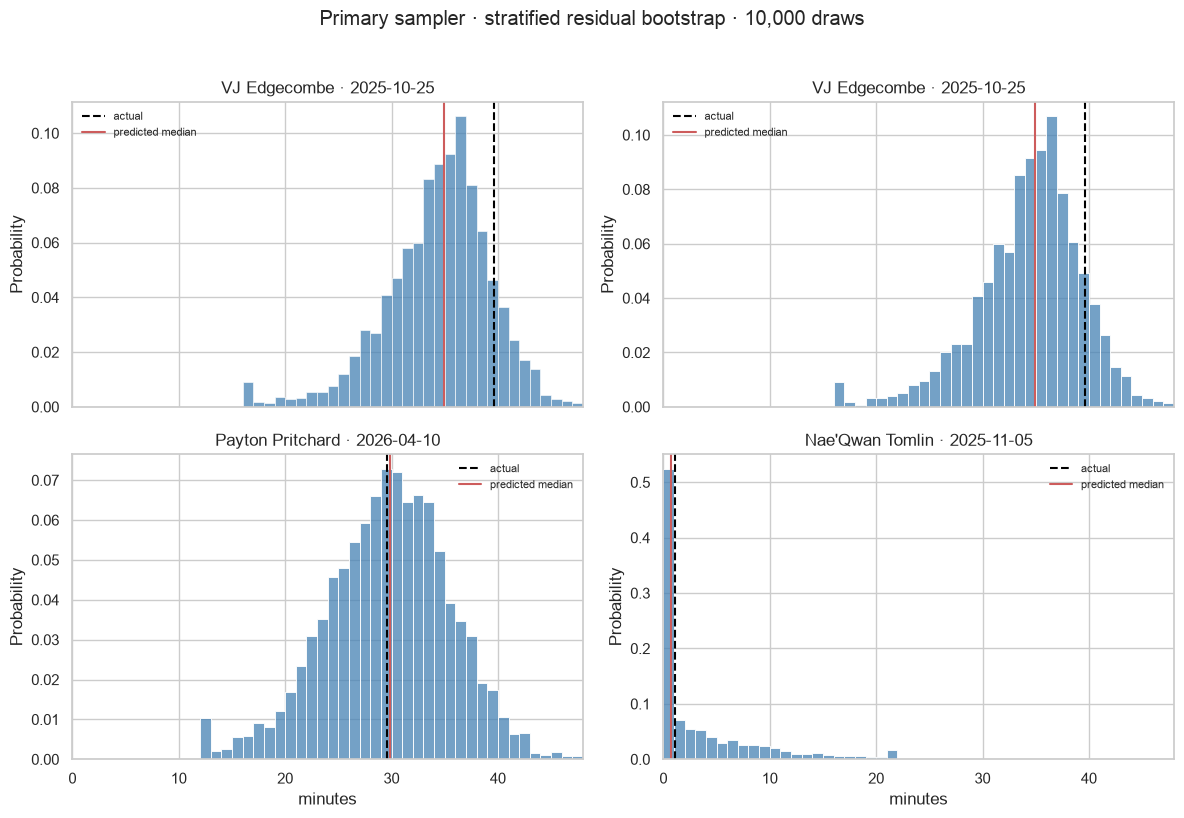

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
for axis, (_, row), draws in zip(axes.ravel(), examples.iterrows(), player_draws):
    sns.histplot(
        draws,
        bins=np.arange(0, MAX_MINUTES + 1, 1),
        stat="probability",
        ax=axis,
        color="steelblue",
    )
    axis.axvline(row["minutes"], color="black", linestyle="--", label="actual")
    axis.axvline(np.median(draws), color="indianred", label="predicted median")
    axis.set_title(f"{row['player_name']} · {pd.Timestamp(row['game_date']).date()}")
    axis.set_xlabel("minutes")
    axis.set_xlim(0, 48)
    axis.legend(frameon=False, fontsize=8)
fig.suptitle(
    "Primary sampler · stratified residual bootstrap · 10,000 draws",
    y=1.02,
)
fig.tight_layout()
plt.show()


In [14]:
def forecast_minutes(
    rows: pd.DataFrame,
    *,
    simulations: int = N_SIM_PLAYER,
    method: str = "stratified_bootstrap",
) -> pd.DataFrame:
    """Pregame minutes distribution for one or more player-games.

    `p_over_avg` is P(minutes > last-10 average). There is no posted
    minutes line in DFS; that probability is the workload tilt.
    """
    if method == "stratified_bootstrap":
        draws = simulate_stratified(
            rows, stratified_pools, simulations=simulations
        )
    elif method == "production_bootstrap":
        draws = model.simulate(rows, simulations=simulations)
    elif method == "quantile_xgb":
        draws = simulate_quantiles(rows, simulations=simulations)
    elif method == "empirical_nn":
        draws = simulate_neighbors(rows, simulations=simulations)
    else:
        raise ValueError(method)

    records = []
    for i, (_, row) in enumerate(rows.iterrows()):
        summary, _ = summarize_draws(
            draws[i],
            threshold=recent_avg_minutes(row),
        )
        records.append(
            {
                "player_name": row.get("player_name"),
                "game_date": row.get("game_date"),
                "matchup": row.get("matchup"),
                "method": method,
                **summary,
            }
        )
    return pd.DataFrame.from_records(records)


# Example: last holdout slate, production API shape.
slate = (
    test.sort_values(["game_date", "min_mean_10"], ascending=[True, False])
    .groupby("game_date", sort=True)
    .tail(8)
    .tail(8)
)
slate_forecast = forecast_minutes(slate, simulations=N_SIM_PLAYER)
display(
    slate_forecast[
        [
            "player_name",
            "game_date",
            "mean",
            "median",
            "std",
            "p10",
            "p50",
            "p90",
            "p_zero",
            "recent_avg",
            "p_over_avg",
            "interval_80_width",
            "mean_mc_se",
        ]
    ].round(3)
)


/var/folders/9q/5_554qsx5z70w9d_vkmvjg0h0000gn/T/ipykernel_16642/3165845231.py:68: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  ].round(3)


,player_name,game_date,mean,median,std,p10,p50,p90,p_zero,recent_avg,p_over_avg,interval_80_width,mean_mc_se
0,DaRon Holmes II,2026-04-12,8.095,6.556,6.091,1.475,6.556,16.657,0.052,3.075,0.804,15.182,0.061
1,Vladislav Goldin,2026-04-12,3.979,1.718,5.260,0.000,1.718,11.592,0.389,2.646,0.431,11.592,0.053
2,John Tonje,2026-04-12,19.374,19.351,6.445,11.388,19.351,27.638,0.000,2.460,0.993,16.250,0.064
3,Zyon Pullin,2026-04-12,5.039,3.096,5.659,0.000,3.096,13.326,0.252,2.036,0.597,13.326,0.057
4,Trevor Keels,2026-04-12,4.000,1.742,5.292,0.000,1.742,11.829,0.386,2.018,0.476,11.829,0.053
5,Tristen Newton,2026-04-12,4.616,2.627,5.509,0.000,2.627,12.604,0.307,2.017,0.553,12.604,0.055
6,Max Shulga,2026-04-12,20.983,20.874,6.552,12.907,20.874,29.499,0.000,1.848,1.000,16.592,0.066
7,Hayden Gray,2026-04-12,11.591,10.074,6.191,4.962,10.074,20.455,0.000,NaN,NaN,15.493,0.062


In [15]:
from src.models.xgboost_models.minutes import MINUTES_DISTRIBUTION_ARTIFACT

model.set_stratified_residual_pools(stratified_pools, MINUTE_BINS)
artifact_path = model.save(MINUTES_DISTRIBUTION_ARTIFACT)

meta_path = ARTIFACT_DIR / "xgboost_minutes_distribution_meta.json"
meta = {
    "artifact_path": str(artifact_path),
    "sampler": "stratified_residual_bootstrap",
    "league": model.league,
    "holdout_season": holdout_season,
    "training_cutoff": str(training_cutoff),
    "n_features": len(model.feature_columns),
    "feature_columns": list(model.feature_columns),
    "minute_bins": MINUTE_BINS.tolist(),
    "pool_sizes": {
        str(bin_id): int(len(pool))
        for bin_id, pool in sorted(stratified_pools.items())
    },
    "n_estimators": int(model.regressor.model.n_estimators),
    "residual_scaling": model.regressor.residual_scaling,
}
meta_path.write_text(json.dumps(meta, indent=2))

reloaded = type(model).load(artifact_path)
smoke_rows = test.head(3)
smoke = reloaded.simulate(smoke_rows, simulations=200)

print(f"Saved production minutes distribution → {artifact_path}")
print(f"Bytes: {artifact_path.stat().st_size:,}")
print(f"Metadata → {meta_path}")
print("Sampler: stratified residual bootstrap")
print(f"Reload simulate shape: {smoke.shape}")
print(
    "Points should load this with "
    "XGBoostMinutesModel.load() and call simulate(rows)."
)
print("Pool sizes:", meta["pool_sizes"])

Saved production minutes distribution → /Users/alexgonzalez/Documents/nba_quant/artifacts/models/minutes/xgboost_minutes_distribution.joblib
Bytes: 6,034,724
Metadata → /Users/alexgonzalez/Documents/nba_quant/artifacts/models/minutes/xgboost_minutes_distribution_meta.json
Sampler: stratified residual bootstrap
Reload simulate shape: (3, 200)
Points should load this with XGBoostMinutesModel.load() and call simulate(rows).
Pool sizes: {'0': 4843, '1': 5276, '2': 5969, '3': 7012, '4': 7013, '5': 894}


## How to read the outputs

- **Mean / median.** Location of the appearance-conditional minutes law. Median is the better point call when the residual pool is skewed.
- **Std / IQR / interval width.** Volatility of minutes, not Monte Carlo error.
- **`mean_mc_se` and `p*_mc_se`.** Monte Carlo uncertainty of the summary statistics. With \(N = 10{,}000\) this should be small. If it is not, raise \(N\).
- **PMF.** Rounded-to-the-minute probability mass from the draws.
- **`p_zero`.** Share of draws that clip to 0. **Not** P(DNP). DNP voids the bet.
- **`p_over_avg`.** `P(minutes > min_mean_10)`. DFS does not post a minutes line. This is the chance tonight exceeds the player's trailing 10-game average — a workload tilt, not a market price.
- **80% / 90% PI.** Percentile intervals from the same draws. CQR is the honest coverage wrapper if raw quantile bands under-cover.

## Production recommendation

1. **Sample with stratified residual bootstrap** on the saved XGBoost mean. Keep the current unstratified `model.simulate()` as a regression test, not as the shipped sampler.
2. **Publish percentile bands from quantile XGBoost** (and optionally wrap 10–90 with CQR) so interval coverage does not depend on the residual-exchangeability assumption.
3. **Do not** put Poisson / NB / Tweedie on minutes. Use them later for points | minutes.
4. **Do not** fold DNP zeros into this density. When a candidate universe exists, add a hurdle for P(play) and keep this module as \(F(\text{minutes} \mid \text{play})\).
5. The fitted stratified sampler is saved to `artifacts/models/minutes/xgboost_minutes_distribution.joblib`. Points should load it with `XGBoostMinutesModel.load()` and call `simulate(rows)` — do not use the mean-only artifact from `xgboost_model.ipynb`.
